# Phase 4 — Finding the Tradeable Pairs

**The idea in one line.** Phase 3 sorted the stocks into a handful of behaviour groups (banks, utilities, property firms, and so on). Belonging to the same group means two stocks *tend* to move alike — but to actually trade them we need something stronger: their price gap has to be "springy", i.e. when it stretches, it reliably pulls back. This notebook checks every pair inside each group for that springiness and keeps only the best.

**Why only test pairs inside a group.** If we tested all ~107,000 possible pairs in the market, pure luck would hand us hundreds that *look* springy but aren't. Testing only within the behaviour groups keeps the number of tests small (so flukes are rare) and means every pair we look at already has a sensible reason to move together.

**Three things we measure for each pair (using 2015–2019 prices):**
1. **Is the gap springy?** A standard statistical test (Engle–Granger) gives a score called the *p-value*; below 0.05 means the springiness is unlikely to be a fluke.
2. **The balancing weight (hedge ratio).** How much of stock B to sell against stock A so the pair ignores the overall market. We lock this in now and reuse it unchanged when we trade in Phase 5.
3. **Speed of the spring (half-life).** Roughly how many days the gap takes to close half of a stretch. Too slow (> 60 days) ties up money for little action; too fast (< 5 days) is just noise.

A second test (Johansen) double-checks the survivors, and a few quality rules trim everything down to the pairs we will actually trade.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from itertools import combinations

assign = pd.read_csv('data/model_input/cluster_assignments.csv', index_col=0)
diag = pd.read_csv('data/model_input/cluster_diagnostics.csv')
stable_ids = diag.loc[diag.stable, 'cluster'].tolist()

prices = pd.read_parquet('data/processed/adj_close_clean.parquet').loc[:'2019-12-31']
logp = np.log(prices)
clusters = {c: assign.index[assign.cluster == c].tolist() for c in stable_ids}
print(f'Stable clusters: {stable_ids}')
print(f'Formation prices: {prices.shape[0]} days, {prices.index.min().date()} -> {prices.index.max().date()}')
print('Cluster sizes:', {c: len(v) for c, v in clusters.items()})

Stable clusters: [0, 8, 2, 1, 3, 9, 7, 6]
Formation prices: 1258 days, 2015-01-02 -> 2019-12-31
Cluster sizes: {0: 23, 8: 24, 2: 4, 1: 16, 3: 3, 9: 3, 7: 4, 6: 3}


## How we test one pair

For a pair of stocks we line up their prices and find the single balancing weight that makes their gap as steady as possible (a plain best-fit line). That weight is the **hedge ratio**, and the leftover wobble around the line is the **gap** we care about.

We then ask two things about that gap:
- **Is it springy?** The Engle–Granger test scores how confidently the gap pulls back toward its average instead of wandering off. The score is the *p-value* — smaller means stronger evidence.
- **How fast does it spring back?** The **half-life** estimates how many days it takes to undo half of a stretch.

The test gives a slightly different answer depending on which stock we treat as the "anchor", so we try it both ways and keep the stronger result. We use the logarithm of prices (a standard tidy-up) so the balancing weight is a clean proportion and the gap reads like a percentage.

In [3]:
def half_life(s):
    ds = np.diff(s)
    lag = s[:-1]
    beta = np.polyfit(lag, ds, 1)[0]
    return -np.log(2) / beta if beta < 0 else np.nan

def eg_pair(a, b):
    y, x = logp[a].values, logp[b].values
    res = sm.OLS(y, sm.add_constant(x)).fit()
    return res.params[1], coint(y, x)[1], half_life(res.resid), res.resid.std()

def best_pair(a, b):
    h1, p1, hl1, sd1 = eg_pair(a, b)
    h2, p2, hl2, sd2 = eg_pair(b, a)
    if p1 <= p2:
        return {'asset1': a, 'asset2': b, 'hedge_ratio': h1, 'eg_pvalue': p1, 'half_life': hl1, 'spread_std': sd1}
    return {'asset1': b, 'asset2': a, 'hedge_ratio': h2, 'eg_pvalue': p2, 'half_life': hl2, 'spread_std': sd2}

In [4]:
rows = []
for c in stable_ids:
    for a, b in combinations(clusters[c], 2):
        r = best_pair(a, b); r['cluster'] = c; rows.append(r)
pairs = pd.DataFrame(rows).sort_values('eg_pvalue').reset_index(drop=True)
print(f'Tested {len(pairs)} within-cluster pairs across {len(stable_ids)} clusters')
pairs.head(10)

Tested 670 within-cluster pairs across 8 clusters


,asset1,asset2,hedge_ratio,eg_pvalue,half_life,spread_std,cluster
0,NTRS,RF,0.618012,0.000175,18.838320,0.035784,8
1,COF,HBAN,0.670682,0.000385,19.780388,0.044556,8
2,HBAN,BAC,0.612143,0.000484,20.685480,0.038448,8
3,MTB,RJF,0.781121,0.000607,23.654957,0.042517,8
4,NTRS,RJF,0.770625,0.000616,25.510909,0.041632,8
5,NTRS,BAC,0.582847,0.000664,27.506385,0.044639,8
6,NTRS,HBAN,0.940913,0.001454,18.865891,0.038724,8
7,NTRS,PNC,0.789117,0.001720,25.675725,0.041933,8
8,MET,C,0.566252,0.001754,24.810237,0.045617,8
9,SCHW,MTB,1.178684,0.001928,30.781513,0.062836,8


## A second opinion (the Johansen test)

The first test looks at the pair from one angle and can be shaky on limited data. The Johansen test asks the same "is this gap springy?" question from a fuller angle, and it is the standard second opinion an examiner will expect to see. We run it on every pair the first test liked and report the **agreement rate** — the share that the second test *also* calls springy. A high agreement rate means our list is not just a quirk of one particular test.

In [5]:
def johansen_ok(a, b):
    m = np.column_stack([logp[a].values, logp[b].values])
    j = coint_johansen(m, 0, 1)
    return bool(j.lr1[0] > j.cvt[0, 1])   # trace stat > 95% critical value (r = 0)

sig = pairs.index[pairs.eg_pvalue < 0.05]
jo = {i: johansen_ok(pairs.at[i, 'asset1'], pairs.at[i, 'asset2']) for i in sig}
pairs['johansen'] = pairs.index.map(jo)          # bool for EG-significant pairs, NaN otherwise
agree = np.mean(list(jo.values())) if jo else float('nan')
print(f'EG-significant pairs (p < 0.05): {len(sig)}')
print(f'Johansen agreement: {agree:.1%}')

EG-significant pairs (p < 0.05): 114
Johansen agreement: 50.0%


## Trimming down to a tradeable short-list

We apply a few rules one after another and count how many pairs survive each step, so the final list is transparent rather than cherry-picked:

1. **Springiness score below 0.05** — keep only pairs whose gap reliably pulls back.
2. **Half-life between 5 and 60 days** — quick enough to trade within a few months, but not so quick it is just noise.
3. **Gap big enough to be worth trading** — drop pairs whose gap is so tiny it could never cover trading costs (we model costs properly later, in Phase 8; this is just a light filter).

The behaviour group each pair comes from already gives the "why would these move together?" story (banks with banks, utilities with utilities), so that common-sense check is built in.

In [6]:
P_MAX, HL_MIN, HL_MAX, SD_MIN = 0.05, 5, 60, 0.01
g1 = pairs[pairs.eg_pvalue < P_MAX]
g2 = g1[g1.half_life.between(HL_MIN, HL_MAX)]
g3 = g2[g2.spread_std >= SD_MIN]
funnel = pd.DataFrame({'gate': ['all within-cluster', 'EG p<0.05', 'half-life 5-60d', 'spread std>=0.01'],
                       'pairs': [len(pairs), len(g1), len(g2), len(g3)]})
print(funnel.to_string(index=False))
shortlist = g3.sort_values('eg_pvalue').reset_index(drop=True)
print('Shortlist pairs:', len(shortlist))
shortlist

              gate  pairs
all within-cluster    670
         EG p<0.05    114
   half-life 5-60d    112
  spread std>=0.01    112
Shortlist pairs: 112


,asset1,asset2,hedge_ratio,eg_pvalue,half_life,spread_std,cluster,johansen
0,NTRS,RF,0.618012,0.000175,18.838320,0.035784,8,True
1,COF,HBAN,0.670682,0.000385,19.780388,0.044556,8,True
2,HBAN,BAC,0.612143,0.000484,20.685480,0.038448,8,True
3,MTB,RJF,0.781121,0.000607,23.654957,0.042517,8,True
4,NTRS,RJF,0.770625,0.000616,25.510909,0.041632,8,True
...,...,...,...,...,...,...,...,...
107,BXP,MAA,0.229989,0.047859,38.577437,0.054391,1,True
108,BK,FITB,0.583831,0.048257,38.880890,0.050404,8,False
109,FITB,BAC,0.717367,0.048658,36.807600,0.049051,8,True
110,WFC,NTRS,0.310638,0.048780,39.983560,0.056885,8,False


## A look at the results

**First chart (four panels).** The gap over time for the four strongest pairs, shown as "how unusual is it right now". The red dashed lines mark the unusually-stretched levels where we would open a trade. What we want to *see* is the line wandering up and down across the middle and repeatedly poking past the red lines — each poke is a trading opportunity, so a good pair gives us plenty.

**Second chart (three panels).**
- **Left — springiness scores of every pair tested.** Bars to the left of the red line (0.05) are the pairs that passed; we are hoping for a healthy cluster down there.
- **Middle — how fast pairs spring back.** The shaded band is our keep-zone (5–60 days). Pairs inside it are tradeable; ones further right are too sluggish.
- **Right — the trimming funnel.** How many pairs were left after each rule, from all of them down to the final short-list.

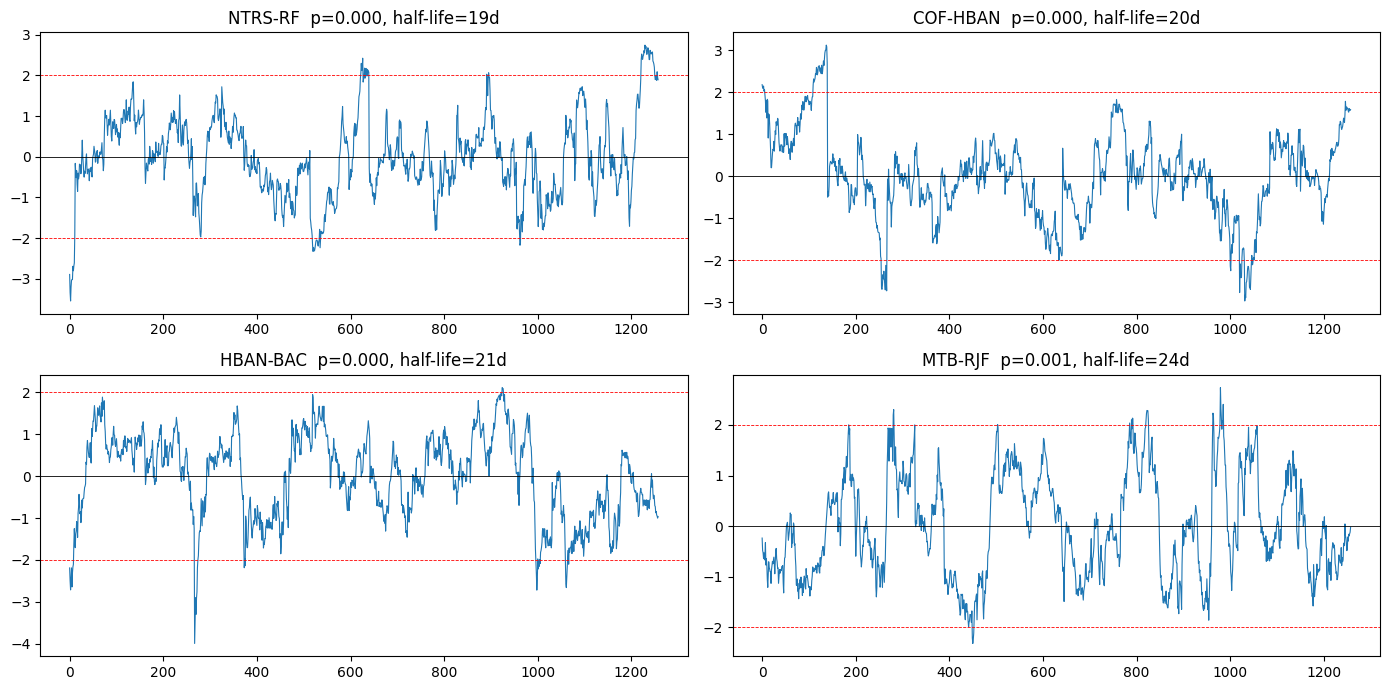

In [7]:
top = shortlist.head(4)
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, r in zip(axes.flat, top.itertuples()):
    spread = logp[r.asset1] - r.hedge_ratio * logp[r.asset2]
    z = (spread - spread.mean()) / spread.std()
    ax.plot(z.values, lw=0.8); ax.axhline(0, color='k', lw=0.6)
    ax.axhline(2, color='r', ls='--', lw=0.6); ax.axhline(-2, color='r', ls='--', lw=0.6)
    ax.set_title(f'{r.asset1}-{r.asset2}  p={r.eg_pvalue:.3f}, half-life={r.half_life:.0f}d')
plt.tight_layout(); plt.show()

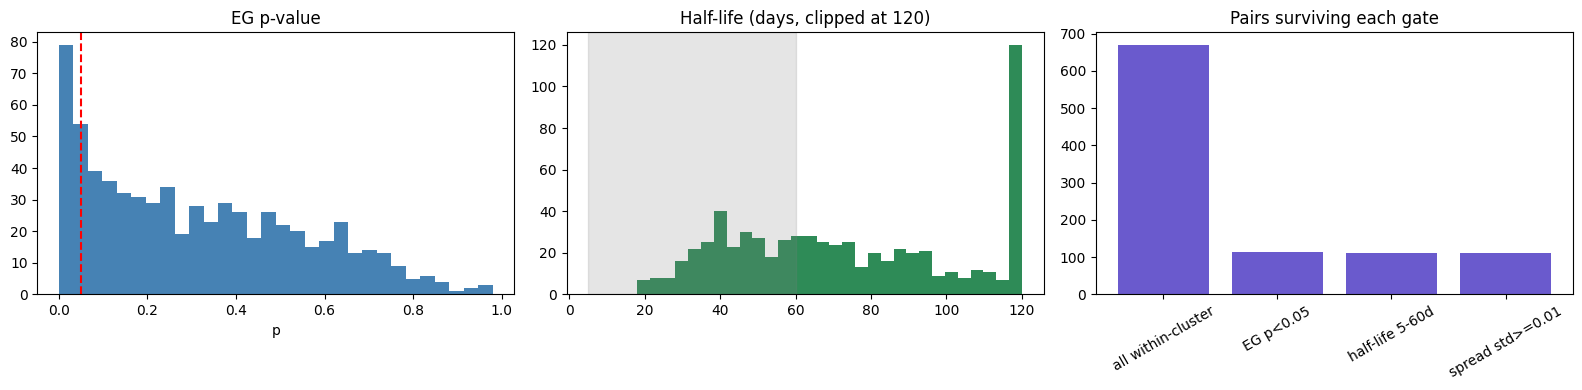

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(pairs.eg_pvalue, bins=30, color='steelblue'); ax[0].axvline(0.05, color='r', ls='--')
ax[0].set_title('EG p-value'); ax[0].set_xlabel('p')
ax[1].hist(pairs.half_life.clip(upper=120).dropna(), bins=30, color='seagreen')
ax[1].axvspan(5, 60, color='grey', alpha=0.2); ax[1].set_title('Half-life (days, clipped at 120)')
ax[2].bar(funnel.gate, funnel.pairs, color='slateblue'); ax[2].tick_params(axis='x', rotation=30)
ax[2].set_title('Pairs surviving each gate')
plt.tight_layout(); plt.show()

## Save the pair lists for Phase 5

- **pairs_all.csv** — every pair we tested, with its balancing weight, springiness score, speed, gap size and second-opinion flag (the full ranked list).
- **pairs_shortlist.csv** — the trimmed, tradeable list that Phase 5 will trade on the unseen 2020+ years.

The balancing weights saved here are locked in — measured only on 2015–2019 and never re-tuned on the years we trade — so the test stays honest.

In [9]:
pairs.to_csv('data/model_input/pairs_all.csv', index=False)
shortlist.to_csv('data/model_input/pairs_shortlist.csv', index=False)
print(f'Saved pairs_all.csv ({len(pairs)} pairs) and pairs_shortlist.csv ({len(shortlist)} pairs)')
print('Top shortlist pairs:')
shortlist.head(12)

Saved pairs_all.csv (670 pairs) and pairs_shortlist.csv (112 pairs)
Top shortlist pairs:


,asset1,asset2,hedge_ratio,eg_pvalue,half_life,spread_std,cluster,johansen
0,NTRS,RF,0.618012,0.000175,18.838320,0.035784,8,True
1,COF,HBAN,0.670682,0.000385,19.780388,0.044556,8,True
2,HBAN,BAC,0.612143,0.000484,20.685480,0.038448,8,True
3,MTB,RJF,0.781121,0.000607,23.654957,0.042517,8,True
4,NTRS,RJF,0.770625,0.000616,25.510909,0.041632,8,True
5,NTRS,BAC,0.582847,0.000664,27.506385,0.044639,8,True
6,NTRS,HBAN,0.940913,0.001454,18.865891,0.038724,8,True
7,NTRS,PNC,0.789117,0.001720,25.675725,0.041933,8,True
8,MET,C,0.566252,0.001754,24.810237,0.045617,8,True
9,SCHW,MTB,1.178684,0.001928,30.781513,0.062836,8,True
